In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.options.display.float_format = '{:,.2f}'.format
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_palette('husl')

con = duckdb.connect('../data/processed/ecommerce.duckdb')
con.execute("""
    CREATE VIEW IF NOT EXISTS ecommerce_clean AS
    SELECT * FROM read_parquet('../data/processed/ecommerce_clean.parquet')
""")

print("Ready!")

Ready!


In [2]:
price_stats = con.execute("""
    WITH stats AS (
        SELECT
            PERCENTILE_CONT(0.25) WITHIN GROUP 
                (ORDER BY price)        AS q1,
            PERCENTILE_CONT(0.75) WITHIN GROUP 
                (ORDER BY price)        AS q3,
            PERCENTILE_CONT(0.75) WITHIN GROUP 
                (ORDER BY price) -
            PERCENTILE_CONT(0.25) WITHIN GROUP 
                (ORDER BY price)        AS iqr
        FROM ecommerce_clean
    )
    SELECT
        s.q1,
        s.q3,
        s.iqr,
        s.q1 - 1.5 * s.iqr             AS lower_fence,
        s.q3 + 1.5 * s.iqr             AS upper_fence,
        COUNT(*) FILTER (
            WHERE price < s.q1 - 1.5 * s.iqr
               OR price > s.q3 + 1.5 * s.iqr
        )                               AS outlier_count,
        COUNT(*)                        AS total_count
    FROM ecommerce_clean, stats s
    GROUP BY s.q1, s.q3, s.iqr
""").df()

q1          = price_stats['q1'].values[0]
q3          = price_stats['q3'].values[0]
iqr         = price_stats['iqr'].values[0]
lower_fence = price_stats['lower_fence'].values[0]
upper_fence = price_stats['upper_fence'].values[0]
outlier_cnt = price_stats['outlier_count'].values[0]
total_cnt   = price_stats['total_count'].values[0]

print("=" * 50)
print("     PRICE ANOMALY DETECTION — IQR METHOD")
print("=" * 50)
print(f"  Q1 (25th percentile) : ${q1:,.2f}")
print(f"  Q3 (75th percentile) : ${q3:,.2f}")
print(f"  IQR                  : ${iqr:,.2f}")
print(f"  Lower Fence          : ${lower_fence:,.2f}")
print(f"  Upper Fence          : ${upper_fence:,.2f}")
print(f"  Outliers detected    : {outlier_cnt:,}")
print(f"  Outlier rate         : {outlier_cnt/total_cnt*100:.2f}%")
print("=" * 50)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

     PRICE ANOMALY DETECTION — IQR METHOD
  Q1 (25th percentile) : $66.66
  Q3 (75th percentile) : $358.57
  IQR                  : $291.91
  Lower Fence          : $-371.20
  Upper Fence          : $796.43
  Outliers detected    : 3,680,390
  Outlier rate         : 8.68%


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

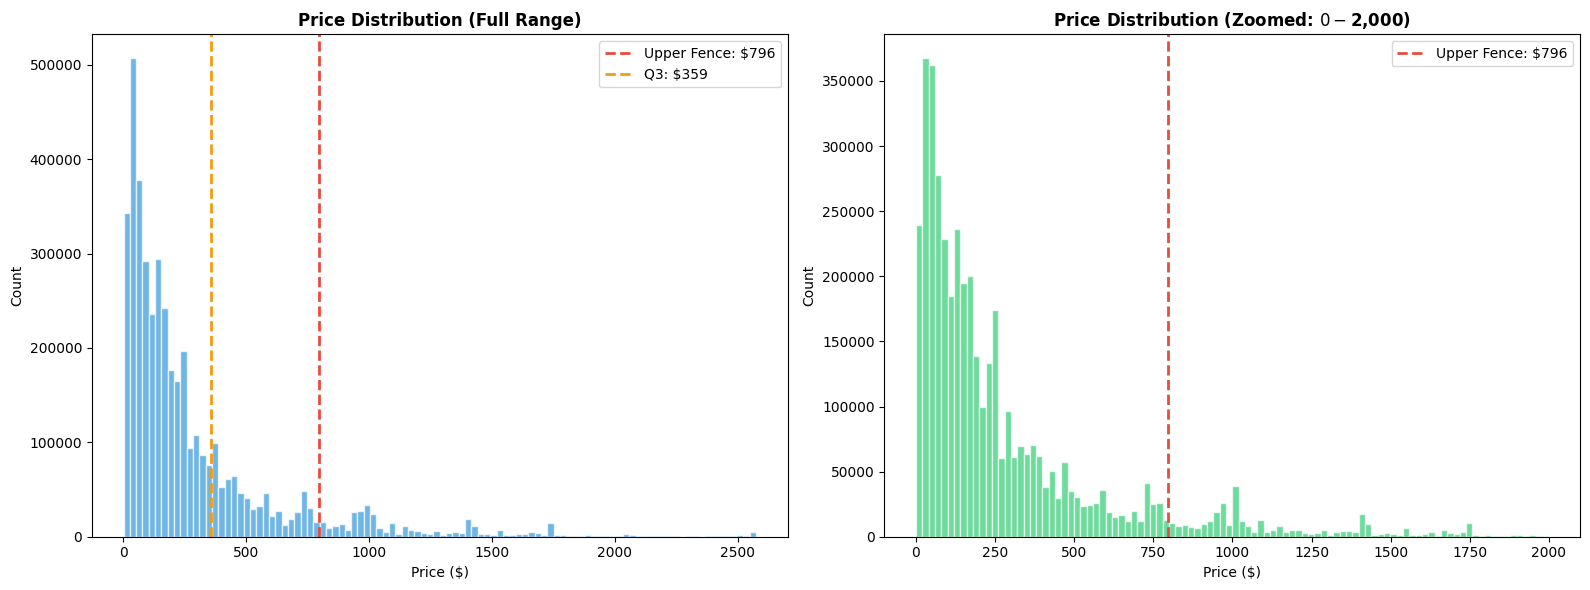

In [8]:
price_sample = con.execute("""
    SELECT price FROM ecommerce_clean
    USING SAMPLE 10 PERCENT (bernoulli)
""").df()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — Full distribution
axes[0].hist(price_sample['price'], bins=100,
             color='#3498db', alpha=0.7, edgecolor='white')
axes[0].axvline(upper_fence, color='#e74c3c',
                linestyle='--', linewidth=2,
                label=f'Upper Fence: ${upper_fence:,.0f}')
axes[0].axvline(q3, color='#f39c12',
                linestyle='--', linewidth=2,
                label=f'Q3: ${q3:,.0f}')
axes[0].set_title('Price Distribution (Full Range)',
                  fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Chart 2 — Zoomed (0-2000)
price_zoomed = price_sample[price_sample['price'] <= 2000]
axes[1].hist(price_zoomed['price'], bins=100,
             color='#2ecc71', alpha=0.7, edgecolor='white')
axes[1].axvline(upper_fence, color='#e74c3c',
                linestyle='--', linewidth=2,
                label=f'Upper Fence: ${upper_fence:,.0f}')
axes[1].set_title('Price Distribution (Zoomed: $0-$2,000)',
                  fontweight='bold')
axes[1].set_xlabel('Price ($)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/19_price_anomaly.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [9]:
suspicious = con.execute("""
    WITH user_stats AS (
        SELECT
            user_id,
            COUNT(*)                        AS total_transactions,
            COUNT(DISTINCT user_session)    AS total_sessions,
            COUNT(DISTINCT event_date)      AS active_days,
            ROUND(SUM(price), 2)            AS total_spending,
            ROUND(AVG(price), 2)            AS avg_price,
            ROUND(MAX(price), 2)            AS max_price,
            MIN(event_date)                 AS first_seen,
            MAX(event_date)                 AS last_seen
        FROM ecommerce_clean
        GROUP BY user_id
    )
    SELECT *,
        ROUND(total_transactions * 1.0 / 
              NULLIF(active_days, 0), 1)    AS trx_per_day,
        CASE
            WHEN total_transactions > 500
             AND active_days <= 5           THEN 'Bot Suspected'
            WHEN total_spending > 500000    THEN 'Whale User'
            WHEN total_transactions > 200   THEN 'Power User'
            WHEN avg_price > 5000           THEN 'Premium Buyer'
            ELSE 'Normal'
        END                                 AS user_flag
    FROM user_stats
    WHERE total_transactions > 100
       OR total_spending > 100000
    ORDER BY total_transactions DESC
    LIMIT 50
""").df()

print("Suspicious & Notable Users:")
display(suspicious[suspicious['user_flag'] != 'Normal']
        [['user_id','total_transactions','active_days',
          'trx_per_day','total_spending','user_flag']])

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Suspicious & Notable Users:


,user_id,total_transactions,active_days,trx_per_day,total_spending,user_flag
0,512475445,7429,32,232.20,"841,213.02",Whale User
1,512365995,4012,31,129.40,"1,499,595.88",Whale User
2,526731152,2912,32,91.00,"935,684.46",Whale User
3,512505687,2894,31,93.40,"684,681.19",Whale User
4,513021392,2862,29,98.70,"487,022.90",Power User
5,546159478,2431,30,81.00,"398,710.20",Power User
6,546270188,2425,22,110.20,"223,296.35",Power User
7,514649263,2388,31,77.00,"257,310.86",Power User
8,516308435,2305,27,85.40,"460,647.03",Power User
9,512401084,2229,20,111.50,"314,913.72",Power User


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

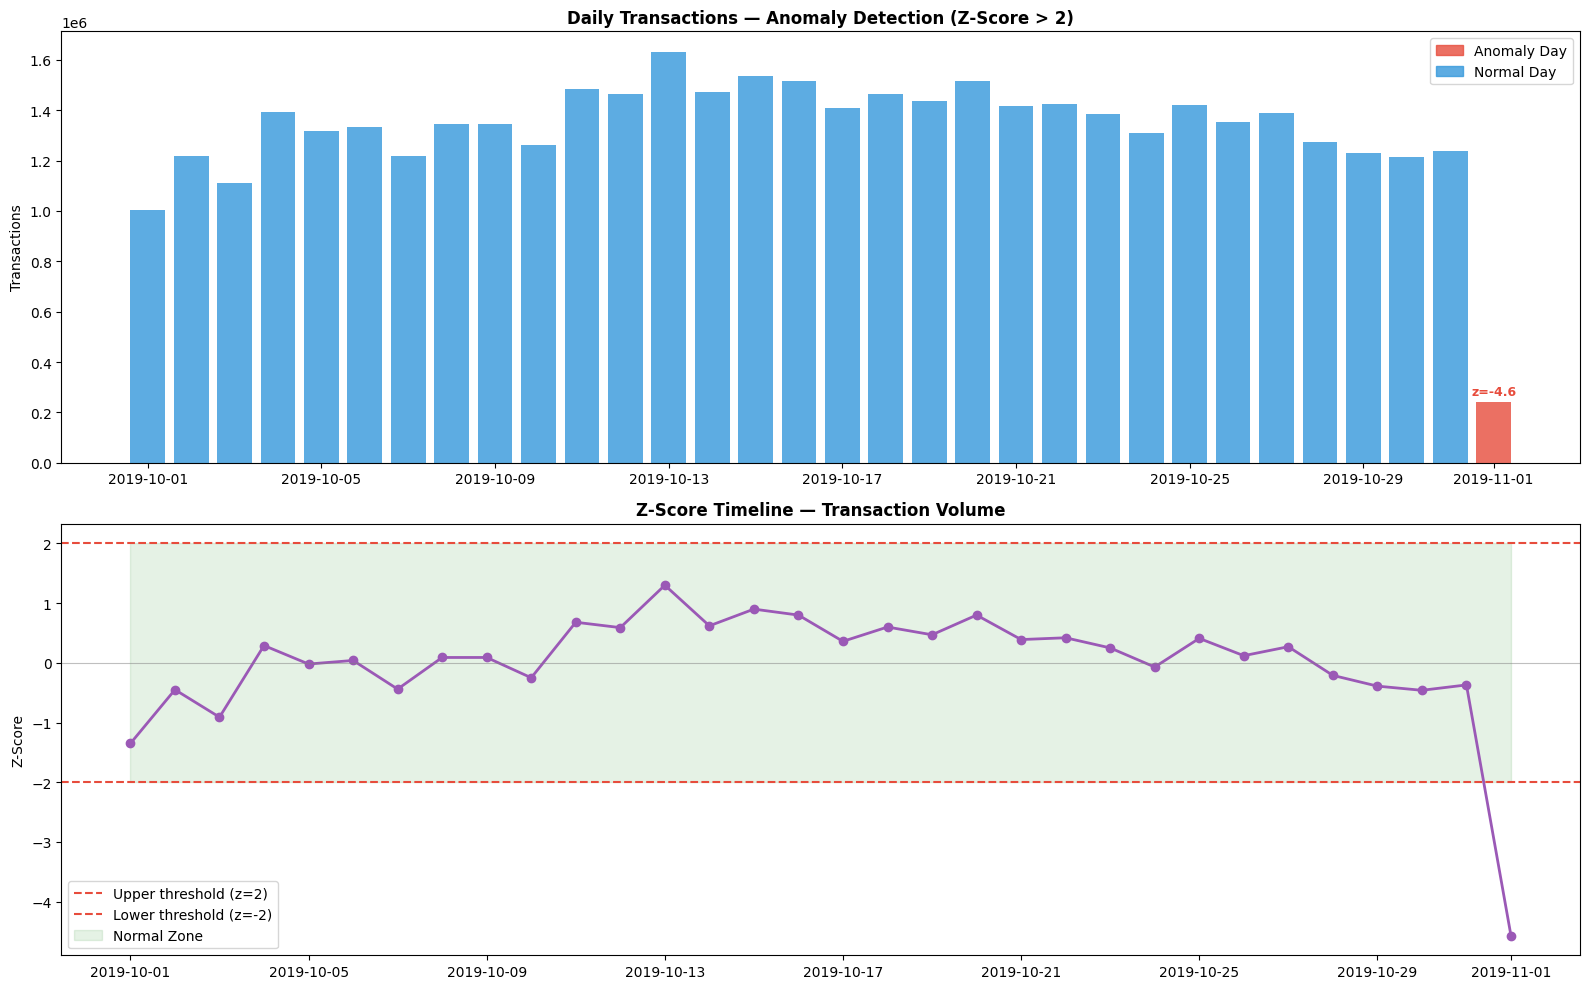


Anomaly Days Detected: 1


,event_date,total_transactions,revenue_millions,z_score
31,2019-11-01,242377,72.87,-4.57


In [10]:
daily_trx = con.execute("""
    SELECT
        event_date,
        COUNT(*)                        AS total_transactions,
        ROUND(SUM(price)/1000000, 2)    AS revenue_millions
    FROM ecommerce_clean
    GROUP BY event_date
    ORDER BY event_date
""").df()

daily_trx['event_date'] = pd.to_datetime(daily_trx['event_date'])

# Z-Score untuk deteksi hari anomali
mean_trx = daily_trx['total_transactions'].mean()
std_trx  = daily_trx['total_transactions'].std()
daily_trx['z_score'] = (
    (daily_trx['total_transactions'] - mean_trx) / std_trx
).round(2)

# Flag anomali (|z| > 2)
daily_trx['is_anomaly'] = daily_trx['z_score'].abs() > 2

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Chart 1 — Daily transactions dengan anomali
colors = ['#e74c3c' if a else '#3498db'
          for a in daily_trx['is_anomaly']]
axes[0].bar(daily_trx['event_date'],
            daily_trx['total_transactions'],
            color=colors, alpha=0.8)

# Annotasi hari anomali
for _, row in daily_trx[daily_trx['is_anomaly']].iterrows():
    axes[0].annotate(
        f"z={row['z_score']:.1f}",
        xy=(row['event_date'], row['total_transactions']),
        xytext=(0, 5), textcoords='offset points',
        ha='center', fontsize=9, color='#e74c3c',
        fontweight='bold'
    )

axes[0].set_title('Daily Transactions — Anomaly Detection (Z-Score > 2)',
                  fontweight='bold')
axes[0].set_ylabel('Transactions')
axes[0].legend(handles=[
    plt.Rectangle((0,0),1,1, color='#e74c3c', alpha=0.8,
                  label='Anomaly Day'),
    plt.Rectangle((0,0),1,1, color='#3498db', alpha=0.8,
                  label='Normal Day')
])

# Chart 2 — Z-Score timeline
axes[1].plot(daily_trx['event_date'],
             daily_trx['z_score'],
             color='#9b59b6', linewidth=2, marker='o')
axes[1].axhline(2,  color='#e74c3c', linestyle='--',
                linewidth=1.5, label='Upper threshold (z=2)')
axes[1].axhline(-2, color='#e74c3c', linestyle='--',
                linewidth=1.5, label='Lower threshold (z=-2)')
axes[1].axhline(0,  color='gray', linestyle='-',
                linewidth=0.8, alpha=0.5)
axes[1].fill_between(daily_trx['event_date'],
                     -2, 2, alpha=0.1, color='green',
                     label='Normal Zone')
axes[1].set_title('Z-Score Timeline — Transaction Volume',
                  fontweight='bold')
axes[1].set_ylabel('Z-Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/20_daily_anomaly.png',
            dpi=150, bbox_inches='tight')
plt.show()

anomaly_days = daily_trx[daily_trx['is_anomaly']]
print(f"\nAnomaly Days Detected: {len(anomaly_days)}")
if len(anomaly_days) > 0:
    display(anomaly_days[['event_date','total_transactions',
                           'revenue_millions','z_score']])

In [11]:
bot_users    = suspicious[suspicious['user_flag']
                          .str.contains('Bot')].shape[0]
whale_users  = suspicious[suspicious['user_flag']
                          .str.contains('Whale')].shape[0]
anomaly_days_count = daily_trx['is_anomaly'].sum()

print("=" * 55)
print("          ANOMALY DETECTION — FINAL REPORT")
print("=" * 55)
print(f"""
PRICE ANOMALIES
   Outliers (IQR method) : {outlier_cnt:,} transactions
   Outlier rate          : {outlier_cnt/total_cnt*100:.2f}%
   Upper price fence     : ${upper_fence:,.2f}
   → Recommend: investigate transactions above fence

SUSPICIOUS USERS
   Bot suspected         : {bot_users} users
   Whale users           : {whale_users} users
   → Bots inflate metrics & distort analysis
   → Whales need VIP handling & fraud monitoring

DAILY ANOMALIES
   Anomaly days detected : {anomaly_days_count} days
   → Investigate spike causes (campaign? fraud? bug?)
   → Use as reference for future campaign planning

DATA INTEGRITY SCORE
   Core columns null     : 0% (perfect)
   Price validity        : {(1 - outlier_cnt/total_cnt)*100:.1f}%
   Overall data quality  : GOOD — fit for analysis
""")
print("=" * 55)

          ANOMALY DETECTION — FINAL REPORT

PRICE ANOMALIES
   Outliers (IQR method) : 3,680,390 transactions
   Outlier rate          : 8.68%
   Upper price fence     : $796.43
   → Recommend: investigate transactions above fence

SUSPICIOUS USERS
   Bot suspected         : 1 users
   Whale users           : 17 users
   → Bots inflate metrics & distort analysis
   → Whales need VIP handling & fraud monitoring

DAILY ANOMALIES
   Anomaly days detected : 1 days
   → Investigate spike causes (campaign? fraud? bug?)
   → Use as reference for future campaign planning

DATA INTEGRITY SCORE
   Core columns null     : 0% (perfect)
   Price validity        : 91.3%
   Overall data quality  : GOOD — fit for analysis



In [12]:
con.close()
print("Anomaly Detection selesai!")
print("\nCharts saved:")
print("   19_price_anomaly.png")
print("   20_daily_anomaly.png")

Anomaly Detection selesai!

Charts saved:
   19_price_anomaly.png
   20_daily_anomaly.png
